# Draft tests

The idea with this script is to test final details of the network before writing a final notebook with the plots and instructions to replicate information in the document. 

In [1]:
# Libraries ------------------------

import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings
from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}

# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel

My fear is that networks are not sufficiently large to reflect the particularities of $\alpha$

In [ ]:
# Test clustering loss in the model: Batch run with small alphas in a large network
params = {"seed": 666, 
          "alpha": np.linspace(0.001, 1, 10),
          'N':[1000],
          "gamma": [0.1], 
          "create_network": "watts_strogatz", 
          "k": [40], 
          "p": [1/1000],
          "rho": 1/3, 
          "one_active_agent_id": [2], 
          "seed_consumption": True, 
          "memory": [5,10,20]}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=1,
    max_steps=90,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

Process SpawnPoolWorker-3:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-6:


KeyboardInterrupt: 

In [ ]:
results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_draft.csv")

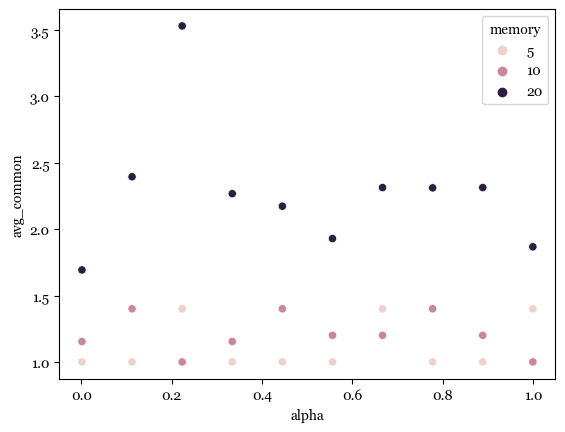

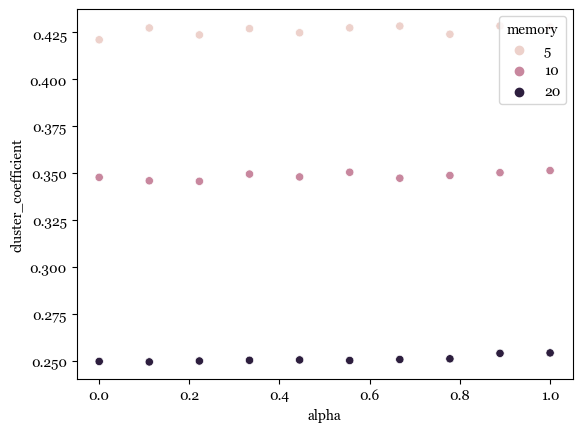

In [ ]:
# Understand results
results_batch_df

# First, take a look at clustering
agent2 = results_batch_df.loc[results_batch_df["AgentID"] == 2]
sns.scatterplot(data=agent2, x="alpha", y="avg_common", hue="memory")
plt.show()
sns.scatterplot(data=agent2, x="alpha", y="cluster_coefficient", hue="memory")
plt.show()

In [ ]:
# Runs to build timelines for multiple alphas --------
runs_multi_alpha = {}

for alpha in np.linspace(0.001, 2, 15):
    one_agent_alpha = OneActiveStatusGameModel(N=1000, one_active_agent_id=2, seed=666, lambda_s=1, memory=10,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=10, rho=1/3, seed_consumption=True, alpha=alpha)
    
    for _ in range(100):
        one_agent_alpha.step()

    print(f"alpha = {alpha}")
    runs_multi_alpha[alpha] = one_agent_alpha.datacollector.get_model_vars_dataframe().reset_index()

Random
alpha = 0.001
Random
Random
Random
Random
Random
Random
alpha = 0.1437857142857143
Random
Random
Random
Random
Random
Random
Random
alpha = 0.2865714285714286
Random
Random
Random
Random
Random
Random
Random
Random
alpha = 0.4293571428571429
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
alpha = 0.5721428571428572
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
alpha = 0.7149285714285715
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
alpha = 0.8577142857142858
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
Random
alpha = 1.0005
Random
Random
Random
Random
Random
Random
Random
Random
Random
Rand

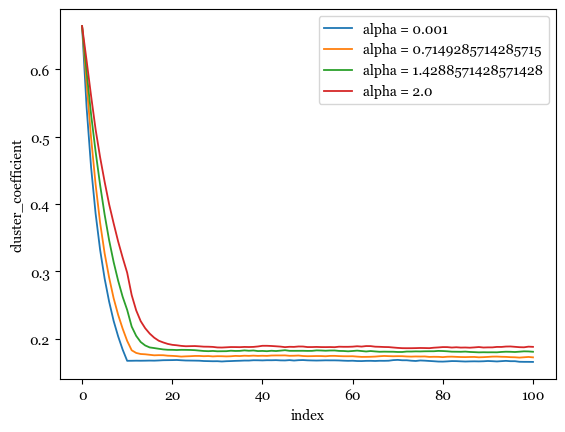

In [ ]:
fig, ax = plt.subplots()
for r in [0,5,10,14]:
    run = list(runs_multi_alpha.keys())[r]
    sns.lineplot(data=runs_multi_alpha[run], x="index", y="cluster_coefficient", label = f"alpha = {run}", ax = ax, linewidth = 1.3)